## Thelia的手撕线性回归尝试！

### 随机生成一个数据集吧~

In [25]:
from pathlib import Path
import random
import numpy as np
import pandas as pd
import time

n_samples = 60
seed = int(time.time())  # 每秒钟更新一次随机种子，确保每次运行生成不同的样本
# 原函数参数 y = a * x + b
random.seed(seed)
a = random.uniform(-4, 4)
b = random.uniform(-10, 10)

# 方差与样本数（方差越大，点越分散）
noise_std = random.uniform(5, 10) * abs(a)
rng = np.random.default_rng(seed)
x = np.arange(1, n_samples + 1)
noise = rng.normal(0, noise_std, size=n_samples)
y = a * x + b + noise

df = pd.DataFrame({
    'x': x,
    'y': np.round(y, 1),
})

csv_path = Path('linear_regression_sample.csv')
df.to_csv(csv_path, index=False)
print(f'已生成 {n_samples} 条样本，保存到: {csv_path.resolve()}')
df.head()

已生成 60 条样本，保存到: /home/thelia/Learn/ML/MyCode/LearningMachineLearning/Thelia/linear_regression_sample.csv


,x,y
0,1,-15.0
1,2,14.8
2,3,9.5
3,4,56.6
4,5,5.2


### 导入包

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 导入数据

In [27]:
dataset = pd.read_csv('linear_regression_sample.csv')
print(dataset)
X = dataset.iloc[:, :-1].values #输入矩阵
y = dataset.iloc[:, -1].values #输出矩阵

     x      y
0    1  -15.0
1    2   14.8
2    3    9.5
3    4   56.6
4    5    5.2
5    6   18.0
6    7   26.3
7    8   45.1
8    9   28.1
9   10   17.8
10  11    0.9
11  12   22.1
12  13    3.8
13  14   27.7
14  15   17.9
15  16   36.9
16  17   60.3
17  18   38.5
18  19   53.2
19  20   70.3
20  21   37.6
21  22   46.1
22  23   47.0
23  24   30.4
24  25   70.9
25  26   94.9
26  27   70.2
27  28   91.3
28  29  100.8
29  30   88.0
30  31   91.5
31  32  130.6
32  33   86.7
33  34   69.7
34  35   94.7
35  36  102.7
36  37  135.6
37  38   87.3
38  39  139.5
39  40  112.2
40  41  118.1
41  42  139.9
42  43  121.7
43  44  118.4
44  45  115.4
45  46  122.9
46  47   82.2
47  48  143.3
48  49  118.9
49  50  164.5
50  51  139.3
51  52  127.4
52  53  166.3
53  54  150.5
54  55  152.4
55  56  151.5
56  57  171.3
57  58  133.7
58  59  155.9
59  60  200.4


#### 试着画个散点图？

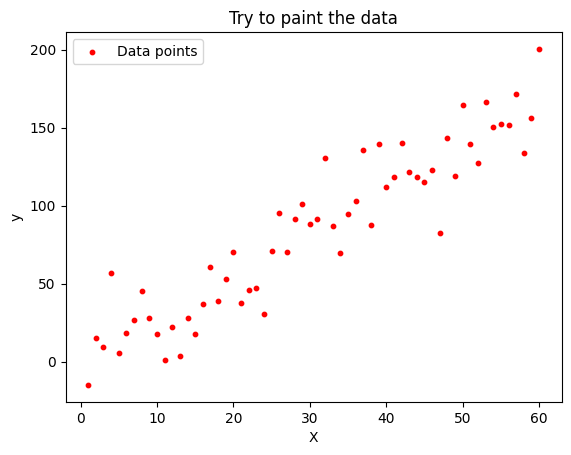

In [28]:
plt.scatter(X, y, color='red', s=10, label='Data points')
plt.title('Try to paint the data')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

### 划分一下训练数据和测试数据~

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0) 

### 线性回归，启动！

In [30]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iters=30000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        n_samples, n_features = X.shape #数据量&特征数
        # 初始化权重和偏置
        self.w = np.zeros(n_features)
        self.b = 0

        # 梯度下降
        for _ in range(self.n_iters):
            y_predicted = np.dot(X, self.w) + self.b
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)

            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.w) + self.b
        return linear_model
        

### 训练一下

In [31]:
LM = LinearRegression()
LM.fit(X_train, y_train)

### 看看结果

Learned parameters: w=2.7307, b=1.3771
True parameters: w=2.8855, b=-1.2839
Test MSE: 268.2847
Preset Variance: 449.7743


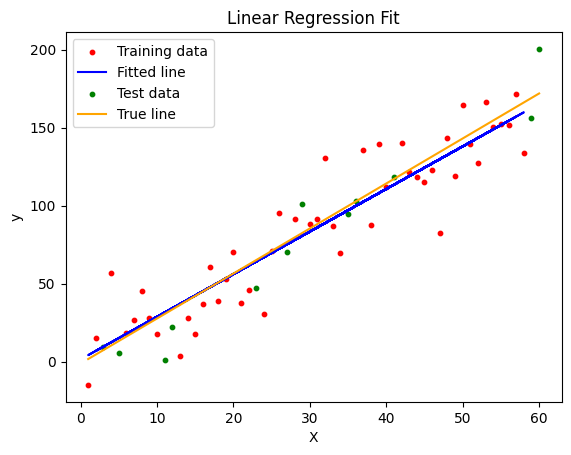

In [32]:
plt.scatter(X_train, y_train, color='red', s=10, label='Training data')
plt.plot(X_train, LM.predict(X_train), color='blue', label='Fitted line')
plt.scatter(X_test, y_test, color='green', s=10, label='Test data')
plt.plot(X, a * X + b, color='orange', label='True line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend(['Training data','Fitted line','Test data','True line'])
print(f'Learned parameters: w={LM.w[0]:.4f}, b={LM.b:.4f}')
print(f'True parameters: w={a:.4f}, b={b:.4f}')
print(f'Test MSE: {np.mean((LM.predict(X_test) - y_test) ** 2):.4f}')
print(f'Preset Variance: {noise_std**2:.4f}')